# Aula 4b: Sampling the posterior with MCMC — the DESI DR2 BAO data

In the previous notebook ([Aula 4a](Aula4a_bayesian_fisher.ipynb)) we introduced the **likelihood**, the **posterior**, and the **Fisher matrix**. The Fisher formalism gives us a Gaussian approximation of the posterior around its maximum: it is fast, but it only tells us how wide the posterior is, not what it really looks like.

In this notebook we do the real thing: we **sample** the posterior with a **Markov Chain Monte Carlo** (MCMC), using our own implementation of the **Metropolis–Hastings** algorithm, and we apply it to a real, current cosmological dataset: the **Baryon Acoustic Oscillation (BAO) measurements from DESI Data Release 2** (2025).

At the end of the notebook you will have measured, from real data and with code you wrote yourself:

$$\Omega_m \simeq 0.298 \pm 0.009 \qquad \text{and} \qquad r_d h \simeq 101.5 \pm 0.7\ \mathrm{Mpc}$$

and you will have reproduced the DESI hint that dark energy may not be a cosmological constant.

**Plan**
1. The BAO standard ruler: what DESI actually measures
2. Loading the DESI DR2 data vector and its covariance
3. The theory model: distances in a FLRW universe
4. The likelihood and the posterior
5. The Metropolis–Hastings algorithm (we write it from scratch)
6. Convergence: burn-in, acceptance rate, correlation length, Gelman–Rubin
7. Results: contours, and comparison with the published DESI constraints
8. Extension: is dark energy a cosmological constant? ($w_0 w_a$CDM)


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

rng = np.random.default_rng(42)   # fixed seed, so that everybody gets the same chains

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 1. The BAO standard ruler

Before recombination, photons and baryons are tightly coupled into a single fluid. An overdensity in this fluid cannot collapse: radiation pressure pushes it outwards and a **spherical sound wave** propagates from every initial perturbation. At recombination ($z \simeq 1090$) the photons decouple, the pressure support disappears, and the wave stalls. It leaves behind a spherical shell of baryons at a fixed comoving radius: the **sound horizon at the drag epoch**,

$$
r_d = \int_{z_d}^{\infty} \frac{c_s(z)}{H(z)} \, \mathrm{d}z \simeq 147\ \mathrm{Mpc},
$$

where $c_s$ is the sound speed of the photon–baryon fluid. This scale is imprinted in the distribution of galaxies today: there is a small excess probability ($\sim 1\%$) of finding two galaxies separated by $r_d$. This is the **BAO feature**, visible as a bump in the correlation function $\xi(r)$ or as wiggles in the power spectrum $P(k)$ — the same wiggles you saw in [Aula 1c](Aula_1c_matter_power_spectrum.ipynb).

Because $r_d$ is a **known length**, the BAO feature is a **standard ruler**. Measuring its apparent size in a galaxy survey gives us distances:

* along the **line of sight**, the ruler is seen as a redshift interval $\Delta z$, which measures the **Hubble distance**
$$D_H(z) = \frac{c}{H(z)} ;$$
* **transverse** to the line of sight, the ruler is seen as an angle $\Delta \theta$, which measures the **comoving angular diameter distance**
$$D_M(z) = \frac{c}{H_0}\int_0^z \frac{\mathrm{d}z'}{E(z')}, \qquad E(z) \equiv \frac{H(z)}{H_0} .$$

When the signal-to-noise is too low to separate the two directions, one measures instead the **angle-averaged distance**

$$
D_V(z) = \left[ z \, D_M^2(z) \, D_H(z) \right]^{1/3} .
$$

A crucial point: a galaxy survey does not measure $D_M$ in Mpc, it measures $D_M$ **in units of the ruler**. The observables are therefore the *dimensionless ratios*

$$
\frac{D_M(z)}{r_d}, \qquad \frac{D_H(z)}{r_d}, \qquad \frac{D_V(z)}{r_d} .
$$

This is why BAO alone cannot measure $H_0$: it measures the combination $H_0 r_d$. To break that degeneracy you need something that predicts $r_d$ (the CMB) or an independent distance ladder (supernovae + Cepheids).

### DESI

The **Dark Energy Spectroscopic Instrument** is a spectrograph on the 4-m Mayall telescope at Kitt Peak, taking 5000 spectra at a time. Its Data Release 2 (DR2, March 2025) BAO analysis uses **over 14 million galaxies and quasars** over $0.1 < z < 4.2$, split into several tracer samples:

| tracer | what it is | redshift range |
|---|---|---|
| BGS | Bright Galaxy Survey (bright, low-$z$ galaxies) | $0.1 - 0.4$ |
| LRG1, LRG2, LRG3 | Luminous Red Galaxies | $0.4 - 1.1$ |
| ELG1, ELG2 | Emission Line Galaxies | $0.8 - 1.6$ |
| QSO | Quasars | $0.8 - 2.1$ |
| Lyα | Lyman-α forest towards distant quasars | $z \simeq 2.3$ |

The Lyα sample is special: there the "galaxies" are absorption features in quasar spectra, which trace the neutral hydrogen along the line of sight and let us measure BAO deep in the matter-dominated era.

We will use the **official public DESI DR2 BAO likelihood data**: the compressed data vector and its covariance matrix, exactly as released by the collaboration.

# 2. The DESI DR2 data vector

The data live in two plain text files:

* `desi_gaussian_bao_ALL_GCcomb_mean.txt` — three columns: effective redshift, measured value, and which quantity it is (`DM_over_rs`, `DH_over_rs` or `DV_over_rs`);
* `desi_gaussian_bao_ALL_GCcomb_cov.txt` — the $13\times13$ covariance matrix of that data vector.

("`rs`" and "$r_d$" denote the same sound horizon here.)

In [2]:
from pathlib import Path

DATA_DIR = Path('../data/desi_dr2_bao')

# data vector: redshift, value, and the type of quantity measured
z_eff, d_obs, quantity = np.genfromtxt(
    DATA_DIR / 'desi_gaussian_bao_ALL_GCcomb_mean.txt',
    dtype=None, encoding=None, unpack=True)

cov = np.loadtxt(DATA_DIR / 'desi_gaussian_bao_ALL_GCcomb_cov.txt')

print('data vector length:', d_obs.size)
print('covariance shape:  ', cov.shape)

data vector length: 13
covariance shape:   (13, 13)


In [3]:
# a readable summary table
sigma = np.sqrt(np.diag(cov))
print(f"{'z_eff':>7} {'quantity':>12} {'value':>9} {'error':>8} {'precision':>10}")
for zi, di, qi, si in zip(z_eff, d_obs, quantity, sigma):
    print(f'{zi:7.3f} {qi:>12} {di:9.3f} {si:8.3f} {100*si/di:9.2f} %')

  z_eff     quantity     value    error  precision
  0.295   DV_over_rs     7.942    0.076      0.96 %
  0.510   DM_over_rs    13.588    0.168      1.24 %
  0.510   DH_over_rs    21.863    0.429      1.96 %
  0.706   DM_over_rs    17.351    0.180      1.04 %
  0.706   DH_over_rs    19.455    0.334      1.72 %
  0.934   DM_over_rs    21.576    0.162      0.75 %
  0.934   DH_over_rs    17.641    0.201      1.14 %
  1.321   DM_over_rs    27.601    0.325      1.18 %
  1.321   DH_over_rs    14.176    0.225      1.58 %
  1.484   DM_over_rs    30.512    0.764      2.50 %
  1.484   DH_over_rs    12.817    0.518      4.04 %
  2.330   DH_over_rs     8.632    0.101      1.17 %
  2.330   DM_over_rs    38.989    0.532      1.36 %


Note how good these measurements are: **sub-percent** distance measurements at several redshifts. Note also that DESI reports $D_V/r_d$ only for the BGS sample: at low redshift the volume is small, so the transverse and radial directions cannot be separated.

The covariance is **block-diagonal**: measurements from different tracers are independent (they use different galaxies and mostly non-overlapping volumes), but within a tracer $D_M/r_d$ and $D_H/r_d$ are anti-correlated, because they are fit simultaneously to the same clustering measurement.

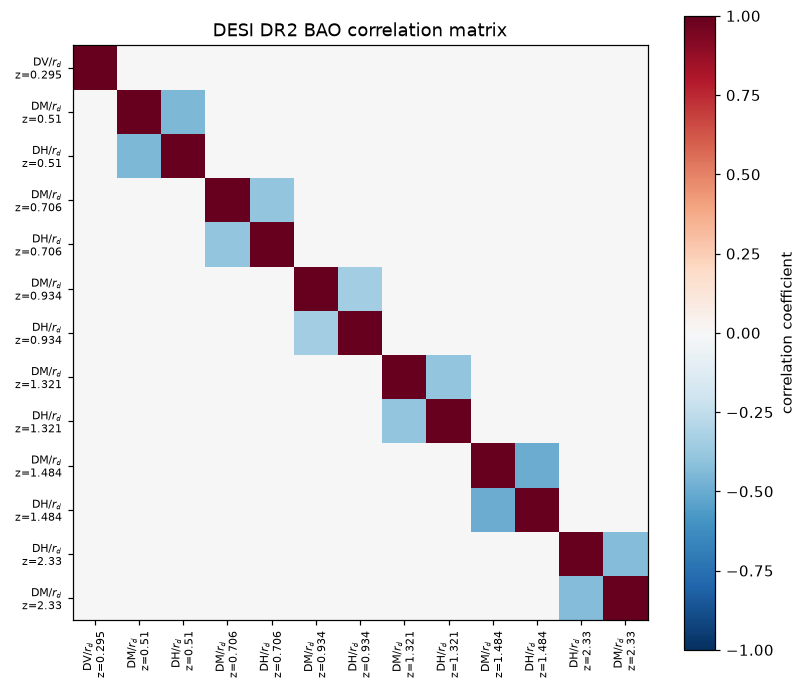

In [4]:
# correlation matrix = normalised covariance
corr = cov / np.outer(sigma, sigma)

labels = [f'{q.replace("_over_rs", "")}/$r_d$\n z={zi}' for q, zi in zip(quantity, z_eff)]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, label='correlation coefficient')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_title('DESI DR2 BAO correlation matrix')
ax.grid(False)
plt.tight_layout()

#### 🧩 Exercise: plot the data

Always look at your data before fitting anything. Because the distances grow quickly with redshift, it is customary to divide them by a power of $z$ to flatten the plot:

* $D_M/(r_d \sqrt{z})$
* $D_H \sqrt{z}/r_d$
* $D_V/(r_d\, z^{2/3})$

Use `plt.errorbar` and select the points with e.g. `mask = quantity == 'DM_over_rs'`.

*A note on what DESI actually plots:* you will not find this exact figure in the DESI papers. Their figures show the distances **divided by a reference model** — figure 6 of the DR2 paper normalises everything by the best-fit $\Lambda$CDM prediction, and figure 1 of the DR1 paper plots $D_V/r_d$ and $F_{\rm AP} = D_M/D_H$ relative to a fiducial cosmology. The reason is that at sub-percent precision the interesting deviations are far smaller than the thickness of the line on an absolute plot like ours. We cannot make that kind of figure yet, because we have no model — we will come back to it in section 7.

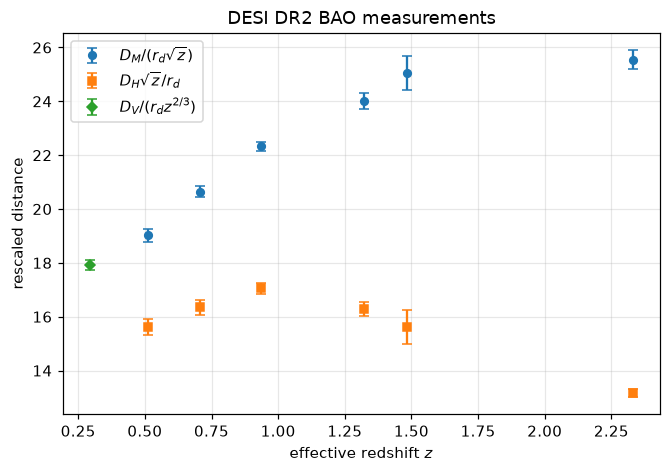

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

styles = {'DM_over_rs': (r'$D_M/(r_d\sqrt{z})$', 'o', 'C0', lambda z: np.sqrt(z)),
          'DH_over_rs': (r'$D_H\sqrt{z}/r_d$',   's', 'C1', lambda z: 1/np.sqrt(z)),
          'DV_over_rs': (r'$D_V/(r_d z^{2/3})$', 'D', 'C2', lambda z: z**(2/3))}

for q, (lab, marker, color, scale) in styles.items():
    m = quantity == q
    if m.sum() == 0:
        continue
    ax.errorbar(z_eff[m], d_obs[m] / scale(z_eff[m]), yerr=sigma[m] / scale(z_eff[m]),
                fmt=marker, color=color, label=lab, capsize=3, ms=5)

ax.set_xlabel('effective redshift $z$')
ax.set_ylabel('rescaled distance')
ax.set_title('DESI DR2 BAO measurements')
ax.legend()

# 3. The theory model

We now need to predict $D_M/r_d$, $D_H/r_d$ and $D_V/r_d$ for a given cosmology.

In a **flat** universe, ignoring radiation (a very good approximation at $z < 5$, where our data are), the Friedmann equation from [Aula 1c](Aula_1c_matter_power_spectrum.ipynb) reads

$$
E^2(z) \equiv \frac{H^2(z)}{H_0^2} = \Omega_m (1+z)^3 + (1 - \Omega_m),
$$

and the distances are

$$
D_H(z) = \frac{c}{H_0}\frac{1}{E(z)}, \qquad
D_M(z) = \frac{c}{H_0}\int_0^z \frac{\mathrm{d}z'}{E(z')}, \qquad
D_V(z) = \left[z D_M^2 D_H\right]^{1/3}.
$$

### Which parameters can we actually measure?

Every observable is a distance **divided by $r_d$**, and every distance carries a prefactor $c/H_0$. So the model always depends on the combination

$$
\frac{c}{H_0 r_d} = \frac{c}{100\ \mathrm{km\,s^{-1}Mpc^{-1}} \times h \, r_d} = \frac{c\,[\mathrm{km/s}]/100}{r_d h \,[\mathrm{Mpc}]}.
$$

BAO data alone therefore constrain exactly **two** parameters:

$$\boxed{\ \theta = (\Omega_m,\ r_d h)\ }$$

where $r_d h$ is in Mpc. There is no way to get $H_0$ and $r_d$ separately from BAO alone — this is a *physical* degeneracy, not a numerical one, and it is worth keeping in mind when we look at the contours later.

#### 🧩 Exercise: implement the model

Write the three functions below. Some hints:

* `quad(f, 0, z)` from `scipy.integrate` returns a tuple `(integral, error_estimate)`, so take `[0]`.
* `theory_vector` must return predictions in **the same order as the data vector**, so loop over `z_eff` and `quantity` together.

In [6]:
C_LIGHT = 299792.458    # speed of light in km/s


def E_of_z(z, Om):
    """Dimensionless expansion rate H(z)/H0 for a flat LCDM universe."""
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))


def distances(z, Om, rd_h):
    """Return (DM/rd, DH/rd, DV/rd) at redshift z.

    Parameters
    ----------
    Om   : matter density parameter today
    rd_h : the combination r_d * h, in Mpc
    """
    prefactor = C_LIGHT / 100.0 / rd_h        # = c / (H0 * rd), dimensionless

    DH_over_rd = prefactor / E_of_z(z, Om)
    DM_over_rd = prefactor * quad(lambda x: 1.0 / E_of_z(x, Om), 0, z)[0]
    DV_over_rd = (z * DM_over_rd**2 * DH_over_rd)**(1/3)

    return DM_over_rd, DH_over_rd, DV_over_rd

def theory_vector(theta):
    """Model prediction, in the same order as the DESI data vector."""
    Om, rd_h = theta
    out = np.empty(z_eff.size)
    for i, (zi, qi) in enumerate(zip(z_eff, quantity)):
        DM, DH, DV = distances(zi, Om, rd_h)
        out[i] = {'DM_over_rs': DM, 'DH_over_rs': DH, 'DV_over_rs': DV}[qi]
    return out

In [7]:
# sanity check: a Planck-like cosmology should already be close to the data
theta_fiducial = np.array([0.315, 99.1])     # Om = 0.315, rd*h = 147.1 * 0.674 Mpc

print(f"{'z':>7} {'quantity':>12} {'data':>9} {'model':>9} {'(d-m)/sigma':>12}")
model_fid = theory_vector(theta_fiducial)
for zi, qi, di, mi, si in zip(z_eff, quantity, d_obs, model_fid, sigma):
    print(f'{zi:7.3f} {qi:>12} {di:9.3f} {mi:9.3f} {(di-mi)/si:12.2f}')

      z     quantity      data     model  (d-m)/sigma
  0.295   DV_over_rs     7.942     8.056        -1.51
  0.510   DM_over_rs    13.588    13.500         0.52
  0.510   DH_over_rs    21.863    22.741        -2.05
  0.706   DM_over_rs    17.351    17.701        -1.94
  0.706   DH_over_rs    19.455    20.172        -2.15
  0.934   DM_over_rs    21.576    21.995        -2.59
  0.934   DH_over_rs    17.641    17.572         0.34
  1.321   DM_over_rs    27.601    28.084        -1.49
  1.321   DH_over_rs    14.176    14.069         0.48
  1.484   DM_over_rs    30.512    30.278         0.31
  1.484   DH_over_rs    12.817    12.884        -0.13
  2.330   DH_over_rs     8.632     8.620         0.12
  2.330   DM_over_rs    38.989    39.189        -0.38


The model is already within a couple of $\sigma$ of the data almost everywhere — but not perfectly. Our job now is to find *which* $(\Omega_m, r_d h)$ fits best, and **with what uncertainty**.

# 4. The likelihood and the posterior

As in [Aula 4a](Aula4a_bayesian_fisher.ipynb), we assume the errors are Gaussian. With a **correlated** data vector, the likelihood generalises from the 1D case to

$$
\mathcal{L}(\mathbf{d}\,;\theta) = \frac{1}{\sqrt{(2\pi)^N \det C}}
\exp\left[-\frac{1}{2}\left(\mathbf{d} - \mathbf{m}(\theta)\right)^T C^{-1} \left(\mathbf{d} - \mathbf{m}(\theta)\right)\right],
$$

where $\mathbf{d}$ is the data vector, $\mathbf{m}(\theta)$ the model, and $C$ the covariance matrix. It is convenient to work with the log-likelihood, and since $C$ does not depend on $\theta$ the normalisation is an irrelevant constant:

$$
\ln \mathcal{L}(\theta) = -\frac{1}{2}\chi^2(\theta) + \mathrm{const}, \qquad
\chi^2(\theta) = \left(\mathbf{d} - \mathbf{m}\right)^T C^{-1} \left(\mathbf{d} - \mathbf{m}\right).
$$

For the **prior** we take flat (uniform) priors on both parameters, wide enough to be uninformative but restricted to the physically sensible region ($\Omega_m > 0$). By Bayes' theorem the log-posterior is then simply

$$
\ln P(\theta | \mathbf{d}) = \ln \mathcal{L}(\theta) + \ln P(\theta) + \mathrm{const}.
$$

A uniform prior returns a constant inside its range and $-\infty$ outside — returning $-\infty$ is how we tell the sampler "never go there".

#### 🧩 Exercise: write the log-posterior

Fill in `log_likelihood`, `log_prior` and `log_posterior`.

Two practical points:
* Invert the covariance **once**, outside the function — not at every likelihood call. This matters: the sampler will call it $10^5$ times.
* In `log_posterior`, evaluate the prior **first** and return immediately if it is $-\infty$. Otherwise you would waste time computing the model for a cosmology you are going to reject anyway (and might get a `NaN` from e.g. a negative $\Omega_m$).

In [8]:
inv_cov = np.linalg.inv(cov)     # computed once and for all


def log_likelihood(theta):
    residual = d_obs - theory_vector(theta)
    return -0.5 * residual @ inv_cov @ residual


def log_prior(theta):
    Om, rd_h = theta
    if 0.05 < Om < 0.7 and 50.0 < rd_h < 150.0:
        return 0.0          # constant inside the box
    return -np.inf          # forbidden outside


def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf      # don't waste time computing the model
    return lp + log_likelihood(theta)


print('ln P at the fiducial point:', log_posterior(theta_fiducial))
print('ln P outside the prior:    ', log_posterior([-0.1, 100.0]))

ln P at the fiducial point: -15.040881853147306
ln P outside the prior:     -inf


### The maximum a posteriori

Before sampling, let us find the *peak* of the posterior with a standard minimiser. This is the **maximum a posteriori** (MAP) — the best-fit point. It gives us a good starting point for the chain, and the $\chi^2$ at that point tells us whether the model fits at all.

In [9]:
best = minimize(lambda t: -log_posterior(t), theta_fiducial, method='Nelder-Mead',
                options=dict(xatol=1e-6, fatol=1e-8))
theta_best = best.x
chi2_best = -2 * log_posterior(theta_best)
ndof = d_obs.size - len(theta_best)

print(f'best fit:  Omega_m = {theta_best[0]:.4f},  rd*h = {theta_best[1]:.2f} Mpc')
print(f'chi2 = {chi2_best:.2f} for {ndof} degrees of freedom  ->  chi2/dof = {chi2_best/ndof:.2f}')

best fit:  Omega_m = 0.2975,  rd*h = 101.54 Mpc
chi2 = 10.27 for 11 degrees of freedom  ->  chi2/dof = 0.93


$\chi^2 \simeq 10.3$ for 11 degrees of freedom: flat $\Lambda$CDM is a perfectly good fit to the DESI DR2 BAO data. (The DESI DR2 paper quotes $\chi^2/\mathrm{dof} = 10.2/(13-2)$ for the same fit — the small difference comes from details of the minimisation, and it is a nice check that our model is right.)

### Why not just scan a grid?

With only two parameters we *could* simply evaluate the posterior on a grid. Let us do it, because it gives us the "ground truth" that our MCMC must reproduce.

number of posterior evaluations: 8100


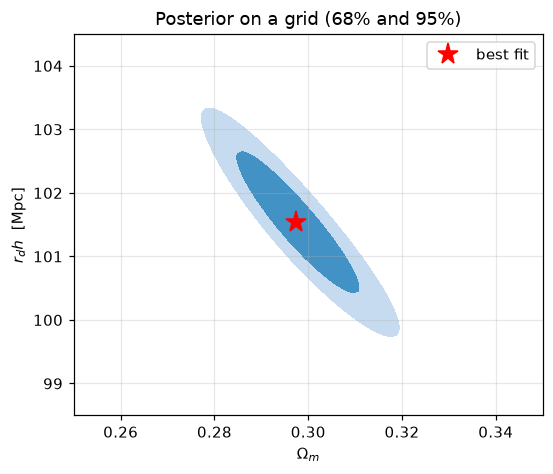

In [10]:
Om_grid = np.linspace(0.25, 0.35, 90)
rdh_grid = np.linspace(98.5, 104.5, 90)

logP_grid = np.array([[log_posterior([om, rdh]) for om in Om_grid] for rdh in rdh_grid])
P_grid = np.exp(logP_grid - logP_grid.max())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
# levels enclosing 68% and 95% of the total probability
flat = np.sort(P_grid.ravel())[::-1]
cumulative = np.cumsum(flat) / flat.sum()
lev68, lev95 = flat[np.searchsorted(cumulative, 0.68)], flat[np.searchsorted(cumulative, 0.95)]

ax.contourf(Om_grid, rdh_grid, P_grid, levels=[lev95, lev68, 1.0], colors=['#c6dbef', '#4292c6'])
ax.plot(*theta_best, 'r*', ms=14, label='best fit')
ax.set_xlabel(r'$\Omega_m$'); ax.set_ylabel(r'$r_d h$  [Mpc]')
ax.set_title('Posterior on a grid (68% and 95%)')
ax.legend()

print(f'number of posterior evaluations: {logP_grid.size}')

The posterior is a narrow, **strongly anti-correlated** ellipse — increasing $\Omega_m$ can be partly compensated by decreasing $r_d h$. Remember this: it will make our first attempt at MCMC inefficient.

The grid took $90^2 = 8100$ evaluations for 2 parameters. With $n$ points per dimension and $p$ parameters the cost is $n^p$: for a realistic cosmological analysis with $p = 6$ (or 20, with nuisance parameters), a grid is completely hopeless — $90^6 \approx 5\times10^{11}$ evaluations, each of which may take a second of CAMB time.

**This is why we need MCMC.** An MCMC does not explore the whole volume: it spends its time where the probability is, and its cost scales roughly *linearly*, not exponentially, with the number of parameters.

# 5. The Metropolis–Hastings algorithm

We want a set of samples $\{\theta_1, \theta_2, \dots\}$ **distributed according to the posterior**, so that we can compute any quantity of interest (means, errors, contours) simply by histogramming them.

The Metropolis–Hastings recipe builds such a set as a *random walk*. Starting from a point $\theta_i$:

1. **Propose** a new point $\theta_\star$ drawn from a *proposal distribution* $q(\theta_\star | \theta_i)$. We use a Gaussian centred on the current point.
2. **Compute** the acceptance ratio
$$\alpha = \min\left[1, \; \frac{P(\theta_\star | d)}{P(\theta_i | d)}\right].$$
3. **Accept or reject**: draw $u \sim \mathcal{U}[0,1]$. If $u < \alpha$, move: $\theta_{i+1} = \theta_\star$. Otherwise stay: $\theta_{i+1} = \theta_i$.
4. Repeat.

Three remarks, which are the whole trick:

* We only ever need the **ratio** of posteriors, so the unknown normalisation $P(d)$ cancels. This is essential — that evidence integral is exactly what we cannot compute.
* If the proposed point is *better*, we always accept. If it is *worse*, we accept it **sometimes**, with probability equal to the ratio. This is what allows the chain to explore the full width of the posterior instead of collapsing onto the peak.
* When we reject, we **write down the current point again**. Do not forget this: the repeated points carry the information that this region is hard to leave, and dropping them biases the density.

In practice we work with logarithms, so step 3 becomes: accept if $\ln u < \ln P(\theta_\star) - \ln P(\theta_i)$.

Because the proposal is symmetric ($q(a|b) = q(b|a)$ for a Gaussian), the Hastings correction factor is 1 and we are doing plain *Metropolis*.

#### 🧩 Exercise: implement Metropolis–Hastings

Write the sampler. Notes:

* The proposal takes a **covariance matrix** `prop_cov`, not just a step size, because we saw the posterior is very anti-correlated. To draw a Gaussian vector with covariance $\Sigma$, use the Cholesky decomposition $\Sigma = LL^T$: then $\theta + L\,\mathbf{u}$, with $\mathbf{u}$ a vector of standard normals, has the right covariance.
* Return the chain, the log-posterior along the chain, and the acceptance rate.
* Evaluate the log-posterior **once per step** (store the current value) — not twice.

In [11]:
def metropolis_hastings(log_post, start, prop_cov, n_steps, rng):
    """Basic Metropolis-Hastings sampler with a Gaussian proposal.

    Parameters
    ----------
    log_post : callable returning ln P(theta) (up to a constant)
    start    : starting point of the chain, shape (ndim,)
    prop_cov : covariance matrix of the Gaussian proposal, shape (ndim, ndim)
    n_steps  : number of steps
    rng      : numpy random generator

    Returns
    -------
    chain     : (n_steps, ndim) array of samples
    log_probs : (n_steps,) array of ln P along the chain
    acc_rate  : fraction of proposals that were accepted
    """
    start = np.asarray(start, dtype=float)
    ndim = start.size
    L = np.linalg.cholesky(prop_cov)          # so that L @ u has covariance prop_cov

    chain = np.empty((n_steps, ndim))
    log_probs = np.empty(n_steps)

    current = start
    current_lp = log_post(current)
    n_accepted = 0

    for i in range(n_steps):
        # 1. propose
        trial = current + L @ rng.standard_normal(ndim)
        trial_lp = log_post(trial)

        # 2. + 3. accept or reject  (in log space)
        if np.log(rng.random()) < trial_lp - current_lp:
            current, current_lp = trial, trial_lp
            n_accepted += 1

        # store the current point, whether we moved or not
        chain[i] = current
        log_probs[i] = current_lp

    return chain, log_probs, n_accepted / n_steps

### A first chain

Let us start the chain far from the best fit on purpose, so that we can watch it find the peak. For the proposal we use, naively, a diagonal covariance with steps of roughly the size we expect the errors to be.

In [12]:
prop_cov_diag = np.diag([0.008, 0.7])**2      # naive diagonal proposal
theta_start = np.array([0.34, 99.0])          # deliberately off the best fit

chain0, logp0, acc0 = metropolis_hastings(log_posterior, theta_start,
                                          prop_cov_diag, 20000, rng)
print(f'acceptance rate: {acc0:.1%}')

acceptance rate: 30.1%


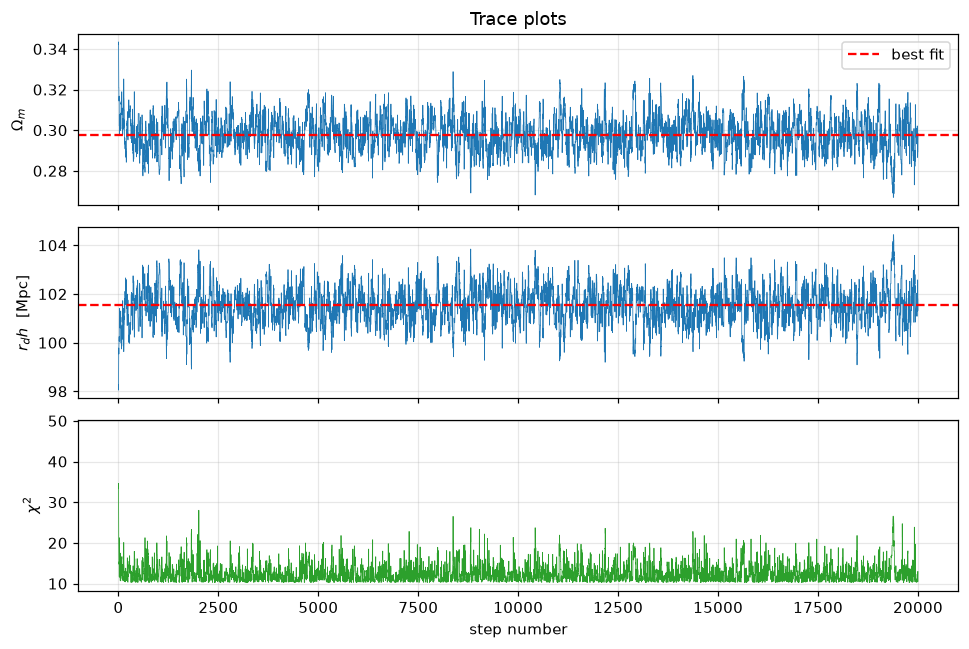

In [13]:
param_names = [r'$\Omega_m$', r'$r_d h$  [Mpc]']

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for k, ax in enumerate(axes[:2]):
    ax.plot(chain0[:, k], lw=0.5)
    ax.axhline(theta_best[k], color='r', ls='--', label='best fit')
    ax.set_ylabel(param_names[k])
axes[0].legend(loc='upper right')

axes[2].plot(-2 * logp0, lw=0.5, color='C2')
axes[2].set_ylabel(r'$\chi^2$'); axes[2].set_ylim(chi2_best - 2, chi2_best + 40)
axes[2].set_xlabel('step number')
axes[0].set_title('Trace plots')
plt.tight_layout()

These are **trace plots**, and they are the first thing you should look at for any chain.

Two features to notice:

* At the very beginning the chain is climbing from the starting point towards the high-probability region. Those first steps are *not* samples of the posterior — they depend on where we chose to start. They are the **burn-in**, and must be discarded.
* After burn-in, the chain looks like noise oscillating around a stable mean, with a stable spread. That is what a converged chain looks like: we say the chain is *stationary*.

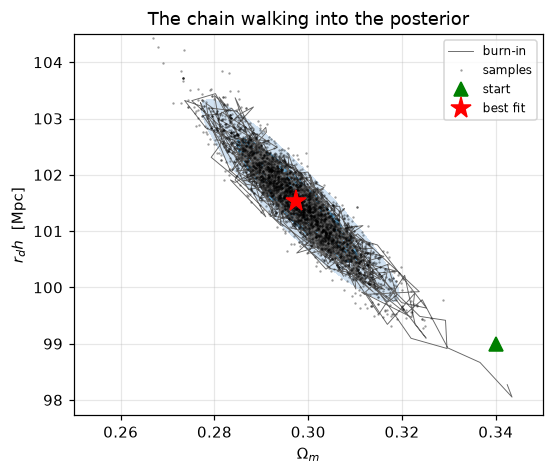

In [14]:
n_burn = 2000
samples0 = chain0[n_burn:]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.contourf(Om_grid, rdh_grid, P_grid, levels=[lev95, lev68, 1.0],
            colors=['#c6dbef', '#4292c6'], alpha=0.8)
ax.plot(chain0[:n_burn, 0], chain0[:n_burn, 1], '-', color='0.4', lw=0.6, label='burn-in')
ax.plot(samples0[::5, 0], samples0[::5, 1], '.', color='k', ms=1, alpha=0.4, label='samples')
ax.plot(*theta_start, 'g^', ms=9, label='start')
ax.plot(*theta_best, 'r*', ms=14, label='best fit')
ax.set_xlabel(r'$\Omega_m$'); ax.set_ylabel(r'$r_d h$  [Mpc]')
ax.set_title('The chain walking into the posterior')
ax.legend(fontsize=8)

The samples fill exactly the ellipse we computed on the grid. **The MCMC works.**

### The step size matters a lot

The proposal covariance is the one thing you have to tune. Let us see what happens when we get it wrong.

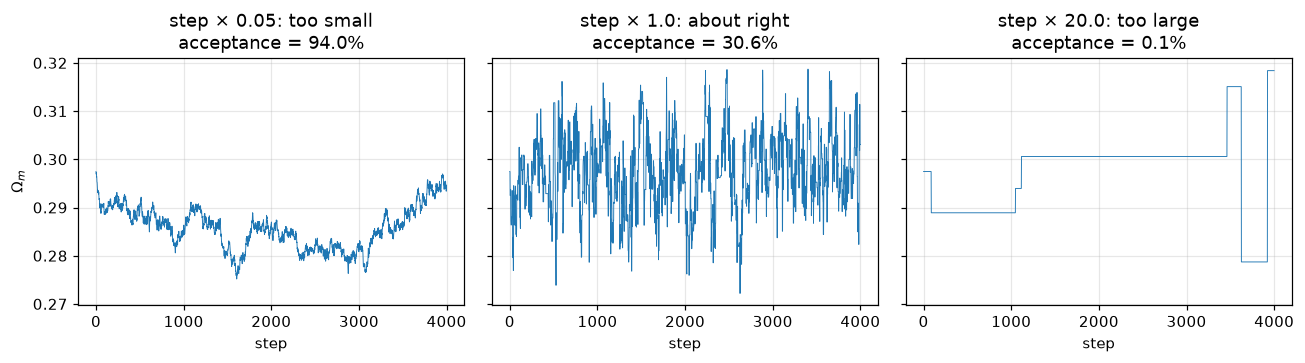

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)

for ax, scale, title in zip(axes, [0.05, 1.0, 20.0],
                            ['too small', 'about right', 'too large']):
    ch, _, acc = metropolis_hastings(log_posterior, theta_best,
                                     prop_cov_diag * scale**2, 4000,
                                     np.random.default_rng(7))
    ax.plot(ch[:, 0], lw=0.6)
    ax.set_title(f'step $\\times$ {scale}: {title}\nacceptance = {acc:.1%}')
    ax.set_xlabel('step')
axes[0].set_ylabel(r'$\Omega_m$')
plt.tight_layout()

* **Too small**: almost every proposal is accepted (acceptance $\to 100\%$), but the chain crawls. It takes a huge number of steps to cross the posterior, so consecutive samples are nearly identical and carry almost no independent information.
* **Too large**: almost every proposal lands far out in the tails and is rejected (acceptance $\to 0$). The trace shows long flat stretches where the chain is stuck at one point.
* **About right**: the chain moves across the posterior in a reasonable number of steps.

There is a classical result for this trade-off: for a Gaussian target in $p$ dimensions, the optimal acceptance rate is $\simeq 0.44$ for $p = 1$ and tends to $\simeq 0.23$ for large $p$. A rule of thumb: **aim for an acceptance rate between 0.2 and 0.4**.

# 6. Is my chain converged?

"Acceptance looks fine" is not enough. Consecutive MCMC samples are **correlated** by construction — the chain is a random walk — so $N$ samples do not carry $N$ independent measurements.

### Autocorrelation and effective sample size

The autocorrelation function of the chain for parameter $k$,

$$
\rho(\tau) = \frac{\langle (\theta_i - \bar\theta)(\theta_{i+\tau} - \bar\theta)\rangle}{\langle(\theta_i - \bar\theta)^2\rangle},
$$

measures how long the chain remembers where it was. The **integrated autocorrelation time** $\tau_{\rm int} = 1 + 2\sum_{\tau \ge 1}\rho(\tau)$ tells us that our $N$ samples are worth only

$$
N_{\rm eff} = \frac{N}{\tau_{\rm int}}
$$

independent ones. That $N_{\rm eff}$ is what sets the error on your final quoted mean.

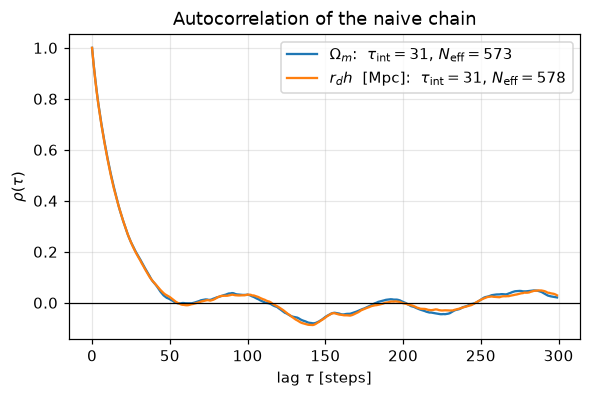

In [16]:
def autocorr(x, max_lag=400):
    """Normalised autocorrelation function of a 1D chain."""
    x = x - x.mean()
    result = np.correlate(x, x, mode='full')[len(x) - 1:]
    return result[:max_lag] / result[0]


def integrated_time(x, c=5.0, max_lag=2000):
    """Integrated autocorrelation time, with the standard automatic window."""
    rho = autocorr(x, max_lag=min(max_lag, len(x) // 2))
    taus = 1.0 + 2.0 * np.cumsum(rho)
    # Sokal's rule: stop summing when the window M reaches c * tau(M)
    m = np.arange(len(taus))
    window = np.argmax(m >= c * taus) if np.any(m >= c * taus) else len(taus) - 1
    return taus[window]


fig, ax = plt.subplots(figsize=(6, 3.6))
for k in range(2):
    tau = integrated_time(samples0[:, k])
    ax.plot(autocorr(samples0[:, k], 300), label=f'{param_names[k]}:  '
            rf'$\tau_{{\rm int}} = {tau:.0f}$, $N_{{\rm eff}} = {len(samples0)/tau:.0f}$')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'lag $\tau$ [steps]'); ax.set_ylabel(r'$\rho(\tau)$')
ax.set_title('Autocorrelation of the naive chain')
ax.legend()

Out of 18000 samples we only have a few hundred *independent* ones. The reason is the strong $\Omega_m$–$r_d h$ degeneracy: our proposal is **diagonal**, so it tries to move along the axes, while the posterior is a thin ellipse tilted at 45°. Almost every step tries to walk out of the ellipse sideways and gets rejected; the chain can only diffuse slowly *along* the degeneracy.

### Tuning the proposal with a pilot run

The fix is simple and is what every real cosmological sampler does: **use a proposal covariance matched to the posterior covariance**. We do not know it in advance, so we estimate it from a short *pilot* chain and rescale it by the standard factor $2.38^2/p$ (which is optimal for a Gaussian target in $p$ dimensions).

In [17]:
ndim = 2
pilot_cov = np.cov(samples0.T)                    # estimated from the naive chain
prop_cov_tuned = pilot_cov * 2.38**2 / ndim

print('posterior covariance estimated from the pilot chain:')
print(pilot_cov)
print(f'\ncorrelation coefficient: {pilot_cov[0,1]/np.sqrt(pilot_cov[0,0]*pilot_cov[1,1]):.3f}')

posterior covariance estimated from the pilot chain:
[[ 7.63784602e-05 -6.07144378e-03]
 [-6.07144378e-03  5.61790874e-01]]

correlation coefficient: -0.927


### Running several chains, and the Gelman–Rubin test

A single chain can look perfectly stationary and still be stuck in one region. The standard safeguard is to run **several chains from different starting points** and check that they all agree.

The **Gelman–Rubin statistic** $R$ compares the variance *between* chains to the variance *within* each chain:

$$
R = \sqrt{\frac{\frac{n-1}{n}W + \frac{1}{n}B}{W}},
$$

where $W$ is the mean within-chain variance and $B$ the between-chain variance. If the chains have converged to the same distribution, $B \simeq W$ and $R \to 1$. In cosmology the usual requirement is $R - 1 < 0.01$.

#### 🧩 Exercise: run 4 tuned chains and check convergence

Run four chains from dispersed starting points using `prop_cov_tuned`, discard the burn-in, and implement the Gelman–Rubin statistic.

In [18]:
def gelman_rubin(chains):
    """R statistic for a list of chains, each of shape (n_steps, ndim)."""
    chains = np.asarray(chains)
    m, n, _ = chains.shape                       # n chains of n steps

    chain_means = chains.mean(axis=1)            # (m, ndim)
    within = chains.var(axis=1, ddof=1).mean(axis=0)          # W
    between = n * chain_means.var(axis=0, ddof=1)             # B

    var_est = (n - 1) / n * within + between / n
    return np.sqrt(var_est / within)


n_chains, n_steps, n_burn = 4, 30000, 5000
starts = theta_best + np.array([[0.02, 1.5], [-0.02, -1.5], [0.015, -1.0], [-0.015, 1.0]])

chains = []
for k in range(n_chains):
    ch, _, acc = metropolis_hastings(log_posterior, starts[k], prop_cov_tuned,
                                     n_steps, np.random.default_rng(100 + k))
    chains.append(ch[n_burn:])
    print(f'chain {k}: acceptance = {acc:.1%}')

R = gelman_rubin(chains)
print('\nGelman-Rubin R - 1:', np.array2string(R - 1, precision=5))
print('converged!' if np.all(R - 1 < 0.01) else 'NOT converged, run longer')

chain 0: acceptance = 35.3%
chain 1: acceptance = 35.2%
chain 2: acceptance = 35.3%
chain 3: acceptance = 35.9%



Gelman-Rubin R - 1: [0.00043 0.00046]
converged!


total samples after burn-in: 100000


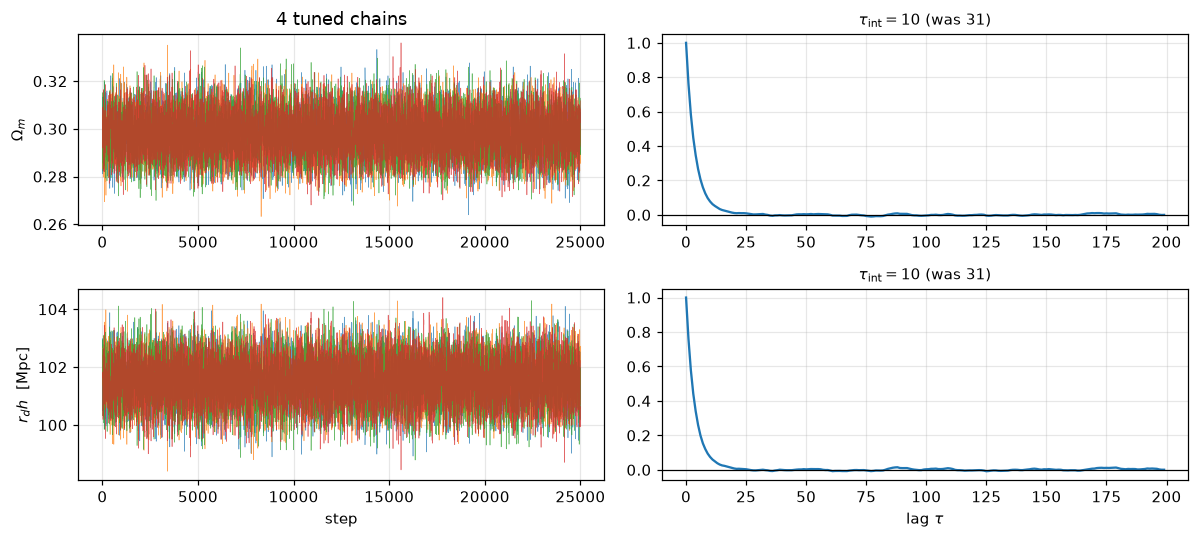

In [19]:
samples = np.concatenate(chains)
print(f'total samples after burn-in: {len(samples)}')

fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for k in range(2):
    for c in chains:
        axes[k, 0].plot(c[:, k], lw=0.4, alpha=0.7)
    axes[k, 0].set_ylabel(param_names[k])
    tau = integrated_time(samples[:, k])
    axes[k, 1].plot(autocorr(samples[:, k], 200))
    axes[k, 1].axhline(0, color='k', lw=0.8)
    axes[k, 1].set_title(rf'$\tau_{{\rm int}} = {tau:.0f}$ '
                         rf'(was {integrated_time(samples0[:, k]):.0f})', fontsize=10)
axes[1, 0].set_xlabel('step'); axes[1, 1].set_xlabel(r'lag $\tau$')
axes[0, 0].set_title('4 tuned chains')
plt.tight_layout()

The correlation length has dropped by roughly a factor 3: with a proposal aligned with the degeneracy, each step actually buys us new information.

**Practical summary — the checklist for any MCMC:**
1. look at the trace plots;
2. discard the burn-in;
3. check the acceptance rate is $\sim 0.2 - 0.4$;
4. tune the proposal covariance (pilot run, or an adaptive sampler);
5. check $\tau_{\rm int}$, and make sure $N_{\rm eff}$ is at least a few hundred;
6. run several chains and check $R - 1 < 0.01$.

# 7. Results: what has DESI measured?

Now that we trust the chain, we can extract the physics. The beauty of having samples is that **everything is now just a histogram**: the marginal posterior of $\Omega_m$ is obtained by simply ignoring the other column of the chain.

We use `getdist`, the standard tool in cosmology for plotting and analysing chains.

Removed no burn in


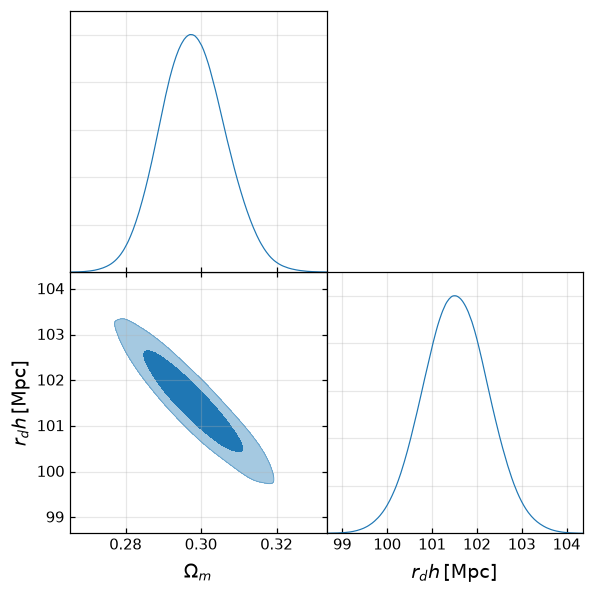

In [20]:
from getdist import MCSamples, plots

gd_samples = MCSamples(samples=samples,
                       names=['Om', 'rdh'],
                       labels=[r'\Omega_m', r'r_d h \,[\mathrm{Mpc}]'],
                       label='DESI DR2 BAO')

g = plots.get_subplot_plotter(width_inch=5.5)
g.triangle_plot([gd_samples], filled=True, contour_colors=['C0'])

In [21]:
print(gd_samples.getTable(limit=1).tableTex())
print()
for name in ['Om', 'rdh']:
    mean = gd_samples.mean(name)
    std = gd_samples.std(name)
    print(f'{name:>4} = {mean:.4f} +/- {std:.4f}')

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\Omega_m       $} & $0.2978\pm 0.0086          $\\

{\boldmath$r_d h \,[\mathrm{Mpc}]$} & $101.52\pm 0.74            $\\
\hline
\end{tabular}

  Om = 0.2978 +/- 0.0086
 rdh = 101.5200 +/- 0.7363


### Comparison with the published DESI result

The DESI DR2 BAO paper quotes, for flat $\Lambda$CDM from BAO alone:

$$\Omega_m = 0.2975 \pm 0.0086, \qquad h r_d = (101.54 \pm 0.73)\ \mathrm{Mpc}, \qquad \chi^2/\mathrm{dof} = 10.2/(13-2).$$

Compare with what you just obtained. This should agree to the third decimal — you have reproduced a published state-of-the-art cosmological constraint with about forty lines of code.

Two things to appreciate here:

* The $\Omega_m$ measurement is at the **3% level**, from BAO alone, with no CMB input.
* The DESI paper notes that these values are in mild ($\sim 2.3\sigma$) tension with the $\Omega_m$ preferred by the CMB. That tension is part of why the DESI results attracted so much attention.

### Comparison with the Fisher forecast

In [Aula 4a](Aula4a_bayesian_fisher.ipynb) we saw that the Fisher matrix approximates the posterior as a Gaussian centred on the best fit, $F_{ij} = -\langle \partial^2 \ln \mathcal{L}/\partial\theta_i\partial\theta_j\rangle$. For a Gaussian likelihood with parameter-independent covariance this is

$$
F_{ij} = \frac{\partial \mathbf{m}^T}{\partial \theta_i} C^{-1} \frac{\partial \mathbf{m}}{\partial \theta_j},
$$

and the predicted errors are $\sigma_i = \sqrt{(F^{-1})_{ii}}$. Let us check that the Fisher approximation is good here.

In [22]:
def fisher_matrix(theta, steps):
    """Fisher matrix, with derivatives of the model taken by finite differences."""
    theta = np.asarray(theta, float)
    derivatives = []
    for i, h in enumerate(steps):
        tp, tm = theta.copy(), theta.copy()
        tp[i] += h; tm[i] -= h
        derivatives.append((theory_vector(tp) - theory_vector(tm)) / (2 * h))
    D = np.array(derivatives)                 # (npar, ndata)
    return D @ inv_cov @ D.T


F = fisher_matrix(theta_best, [1e-4, 1e-2])
fisher_cov = np.linalg.inv(F)

print('              MCMC        Fisher')
for k, name in enumerate(['Om ', 'rdh']):
    print(f'sigma({name}) = {samples[:, k].std():9.4f}  {np.sqrt(fisher_cov[k, k]):9.4f}')
r_mcmc = np.corrcoef(samples.T)[0, 1]
r_fish = fisher_cov[0, 1] / np.sqrt(fisher_cov[0, 0] * fisher_cov[1, 1])
print(f'correlation  = {r_mcmc:9.3f}  {r_fish:9.3f}')

              MCMC        Fisher
sigma(Om ) =    0.0086     0.0086
sigma(rdh) =    0.7363     0.7328
correlation  =    -0.924     -0.923


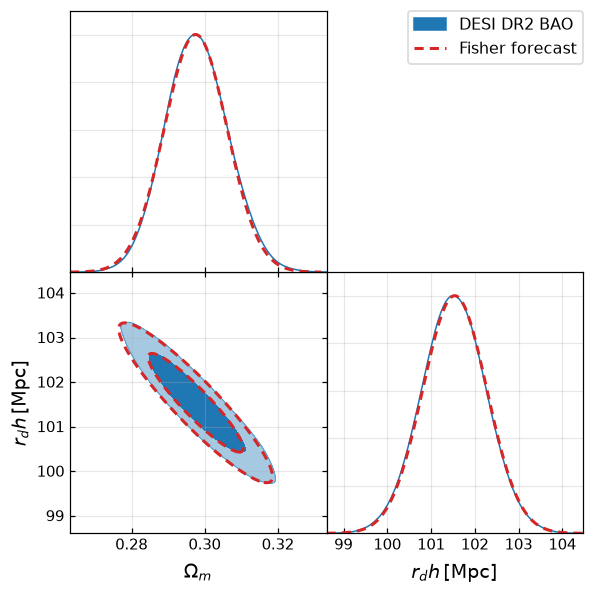

In [23]:
from getdist.gaussian_mixtures import GaussianND

fisher_gauss = GaussianND(theta_best, fisher_cov, names=['Om', 'rdh'],
                          labels=[r'\Omega_m', r'r_d h \,[\mathrm{Mpc}]'],
                          label='Fisher forecast')

g = plots.get_subplot_plotter(width_inch=5.5)
g.triangle_plot([gd_samples, fisher_gauss], filled=[True, False],
                contour_colors=['C0', 'C3'], contour_ls=['-', '--'], contour_lws=[1, 2])

The Fisher ellipse is an excellent approximation here, because with 13 well-measured data points and only 2 parameters the posterior really is close to Gaussian. That will **not** be true in section 8, where the posterior gets strongly non-Gaussian — and that is precisely when you must run an MCMC instead of trusting a Fisher forecast.

### The best fit against the data

Finally, the plot you should always make: the model at the best-fit parameters, on top of the data. The lower panel — the residuals with respect to the best fit — is the honest version of the DESI figure we could not draw in section 2: this is essentially the information contained in figure 6 of the DR2 paper.

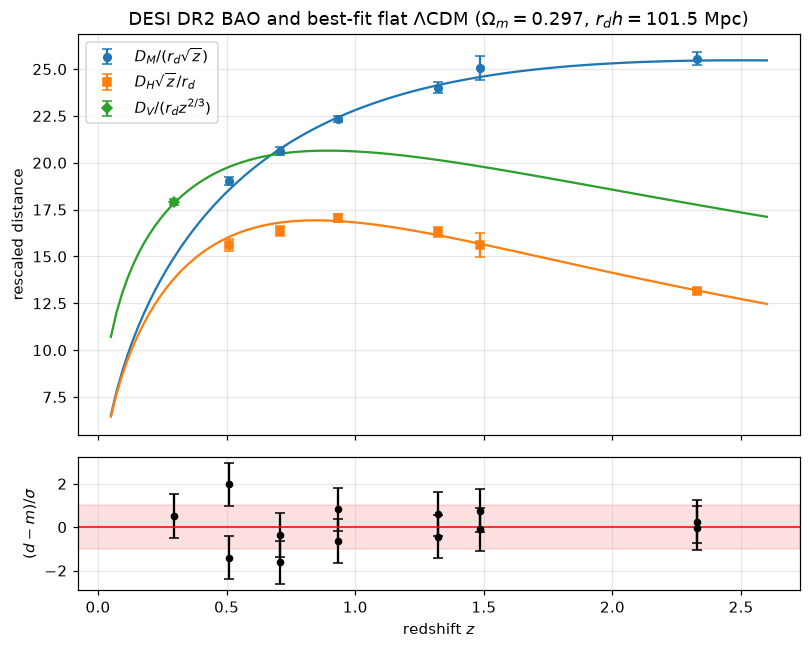

In [24]:
z_smooth = np.linspace(0.05, 2.6, 120)
pred = np.array([distances(zz, *theta_best) for zz in z_smooth])   # DM, DH, DV

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1]))

for j, (q, (lab, marker, color, scale)) in enumerate(styles.items()):
    ax.plot(z_smooth, pred[:, j] / scale(z_smooth), color=color, lw=1.5)
    m = quantity == q
    if m.sum():
        ax.errorbar(z_eff[m], d_obs[m] / scale(z_eff[m]), yerr=sigma[m] / scale(z_eff[m]),
                    fmt=marker, color=color, label=lab, capsize=3, ms=5, ls='none')

ax.set_ylabel('rescaled distance')
ax.set_title(rf'DESI DR2 BAO and best-fit flat $\Lambda$CDM '
             rf'($\Omega_m = {theta_best[0]:.3f}$, $r_d h = {theta_best[1]:.1f}$ Mpc)')
ax.legend()

residuals = (d_obs - theory_vector(theta_best)) / sigma
axr.errorbar(z_eff, residuals, yerr=1.0, fmt='ko', ms=4, capsize=3)
axr.axhline(0, color='r', lw=1)
axr.axhspan(-1, 1, color='r', alpha=0.12)
axr.set_ylabel(r'$(d - m)/\sigma$'); axr.set_xlabel('redshift $z$')
plt.tight_layout()

# 8. Extension: is dark energy a cosmological constant?

So far we assumed dark energy is a cosmological constant $\Lambda$, with equation of state $w \equiv p/\rho c^2 = -1$, constant in time. This is an *assumption*, and BAO measurements of the expansion history are exactly the kind of data that can test it.

The standard phenomenological generalisation is the **CPL parametrisation**, in which $w$ evolves linearly with the scale factor $a = 1/(1+z)$:

$$
w(a) = w_0 + w_a (1 - a) = w_0 + w_a \frac{z}{1+z}.
$$

So $w_0$ is the equation of state today, and $w_a$ measures its evolution. $\Lambda$CDM is the point $(w_0, w_a) = (-1, 0)$.

Solving the continuity equation $\dot\rho_{\rm de} + 3H(1+w)\rho_{\rm de} = 0$ with this $w(a)$ gives the dark energy density evolution, and the Friedmann equation becomes

$$
E^2(z) = \Omega_m(1+z)^3 + (1-\Omega_m)\,(1+z)^{3(1+w_0+w_a)} \exp\left(\frac{-3 w_a z}{1+z}\right).
$$

You can check that setting $w_0 = -1, w_a = 0$ gives back the constant $(1-\Omega_m)$ we had before.

This was the headline result of DESI 2024 and 2025: the data appear to prefer $w_0 > -1$ and $w_a < 0$ — dark energy that was "phantom" in the past and is weakening today — at a significance of a few $\sigma$ when combined with CMB and supernovae. Let us see what the BAO data alone say.

#### 🧩 Exercise: generalise the model and sample 4 parameters

You need to:
1. write `E_of_z_cpl(z, Om, w0, wa)`;
2. write `theory_vector_cpl(theta)` with `theta = (Om, rd_h, w0, wa)`;
3. write the corresponding `log_posterior_cpl`, with flat priors — use $-3 < w_0 < 1$ and $-3 < w_a < 2$;
4. run a pilot chain, tune the proposal, then run 4 chains and check convergence.

Careful with one thing: for extreme $(w_0, w_a)$ the expression inside the square root can go negative. Guard against it (`np.errstate` or an explicit check) so you do not get `NaN`s.

In [25]:
def E_of_z_cpl(z, Om, w0, wa):
    """Dimensionless expansion rate for flat w0waCDM (CPL parametrisation)."""
    rho_de = (1 - Om) * (1 + z)**(3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))
    return np.sqrt(Om * (1 + z)**3 + rho_de)


def theory_vector_cpl(theta):
    Om, rd_h, w0, wa = theta
    prefactor = C_LIGHT / 100.0 / rd_h
    E = lambda zz: E_of_z_cpl(zz, Om, w0, wa)

    out = np.empty(z_eff.size)
    for i, (zi, qi) in enumerate(zip(z_eff, quantity)):
        DH = prefactor / E(zi)
        DM = prefactor * quad(lambda x: 1.0 / E(x), 0, zi)[0]
        out[i] = {'DM_over_rs': DM, 'DH_over_rs': DH,
                  'DV_over_rs': (zi * DM**2 * DH)**(1/3)}[qi]
    return out


def log_posterior_cpl(theta):
    Om, rd_h, w0, wa = theta
    if not (0.05 < Om < 0.7 and 50.0 < rd_h < 150.0 and -3.0 < w0 < 1.0 and -3.0 < wa < 2.0):
        return -np.inf
    with np.errstate(invalid='ignore', over='ignore'):
        residual = d_obs - theory_vector_cpl(theta)
    if not np.all(np.isfinite(residual)):
        return -np.inf
    return -0.5 * residual @ inv_cov @ residual


print('ln P at the LCDM point:', log_posterior_cpl([*theta_best, -1.0, 0.0]))

ln P at the LCDM point: -5.135520501283324


In [26]:
# pilot run with a rough diagonal guess, then tune the proposal on it
ndim_cpl = 4
start_cpl = np.array([0.30, 101.5, -1.0, 0.0])
pilot_diag = np.diag([0.03, 1.2, 0.30, 0.9])**2

pilot, _, acc_pilot = metropolis_hastings(log_posterior_cpl, start_cpl, pilot_diag,
                                          5000, np.random.default_rng(1))
print(f'pilot acceptance: {acc_pilot:.1%}   <- terrible, as expected')

prop_cov_cpl = np.cov(pilot[1000:].T) * 2.38**2 / ndim_cpl

pilot acceptance: 1.3%   <- terrible, as expected


In [27]:
chains_cpl = []
for k in range(4):
    ch, _, acc = metropolis_hastings(log_posterior_cpl, pilot[-1], prop_cov_cpl,
                                     40000, np.random.default_rng(200 + k))
    chains_cpl.append(ch[8000:])
    print(f'chain {k}: acceptance = {acc:.1%}')

R_cpl = gelman_rubin(chains_cpl)
print('\nGelman-Rubin R - 1:', np.array2string(R_cpl - 1, precision=4))

samples_cpl = np.concatenate(chains_cpl)

chain 0: acceptance = 26.7%


chain 1: acceptance = 27.0%


chain 2: acceptance = 26.4%


chain 3: acceptance = 26.5%

Gelman-Rubin R - 1: [0.0007 0.0009 0.0011 0.0007]


Removed no burn in


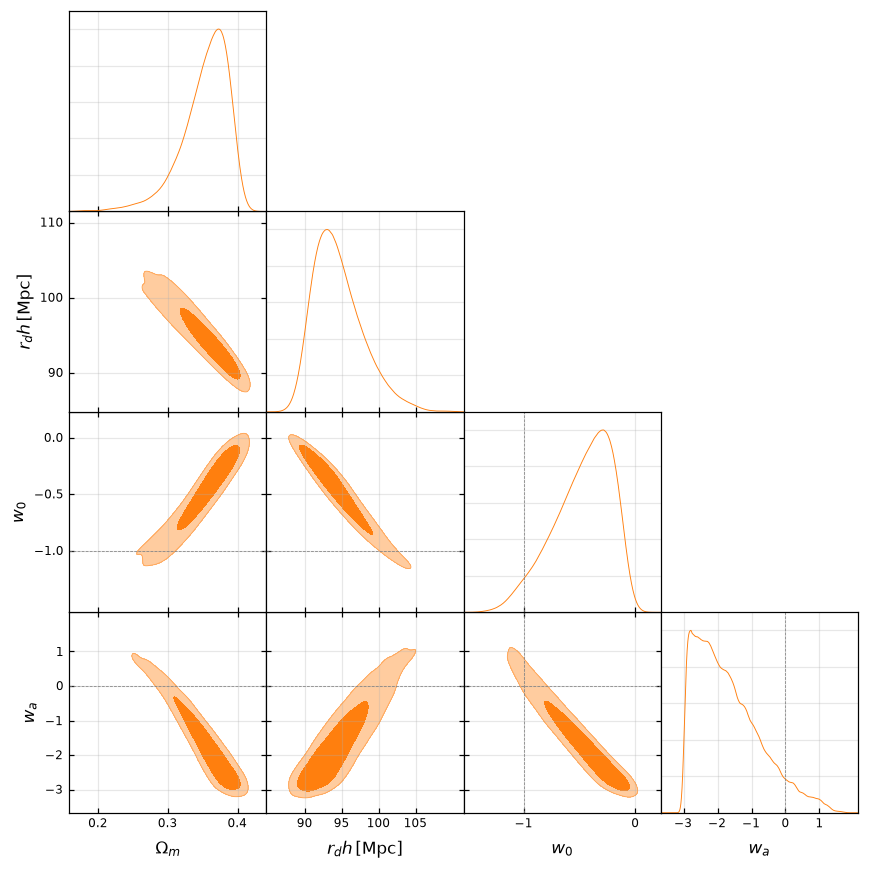

In [28]:
gd_cpl = MCSamples(samples=samples_cpl,
                   names=['Om', 'rdh', 'w0', 'wa'],
                   labels=[r'\Omega_m', r'r_d h\,[\mathrm{Mpc}]', 'w_0', 'w_a'],
                   label=r'DESI DR2 BAO, $w_0w_a$CDM')

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([gd_cpl], filled=True, contour_colors=['C1'],
                markers={'w0': -1.0, 'wa': 0.0})

  Om =    0.354 +/- 0.035
 rdh =   94.530 +/- 3.429
  w0 =   -0.469 +/- 0.265
  wa =   -1.687 +/- 0.959

fraction of samples with wa < -2.8 (prior edge at -3): 8.9%


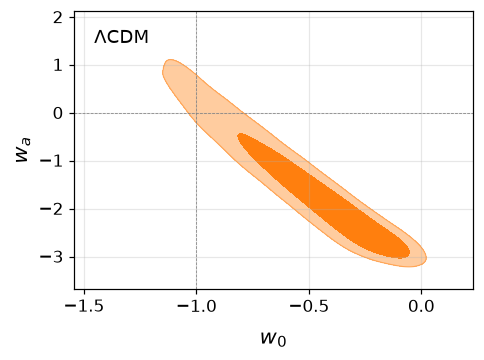

In [29]:
for name in ['Om', 'rdh', 'w0', 'wa']:
    print(f'{name:>4} = {gd_cpl.mean(name):8.3f} +/- {gd_cpl.std(name):.3f}')

# careful: is any parameter running into its prior boundary?
frac_at_edge = np.mean(samples_cpl[:, 3] < -2.8)
print(f'\nfraction of samples with wa < -2.8 (prior edge at -3): {frac_at_edge:.1%}')

# how far is LCDM (w0=-1, wa=0) from the peak of this 2D posterior?
g = plots.get_single_plotter(width_inch=4.5)
g.plot_2d([gd_cpl], 'w0', 'wa', filled=True, colors=['C1'])
g.add_x_marker(-1.0); g.add_y_marker(0.0)
g.add_text(r'$\Lambda$CDM', 0.05, 0.9, color='k')

In [30]:
# how much better does the extra freedom actually fit the data?
best_cpl = minimize(lambda t: -log_posterior_cpl(t), samples_cpl.mean(axis=0),
                    method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-9, maxiter=20000))
chi2_cpl = -2 * log_posterior_cpl(best_cpl.x)

print(f'LCDM     : chi2 = {chi2_best:.2f} for {d_obs.size - 2} dof')
print(f'w0waCDM  : chi2 = {chi2_cpl:.2f} for {d_obs.size - 4} dof')
print(f'\ndelta chi2 = {chi2_best - chi2_cpl:.2f} for 2 extra parameters')

from scipy.stats import chi2 as chi2_dist
p_value = chi2_dist.sf(chi2_best - chi2_cpl, 2)
print(f'p-value = {p_value:.3f}  ->  {np.sqrt(chi2_dist.isf(p_value, 1)):.1f} sigma preference')

# this is exactly the procedure of eq. 22 of the DESI DR2 paper: LCDM is nested
# inside w0waCDM, so by Wilks' theorem delta chi2 follows a chi2 distribution with
# 2 dof, which we then translate into an equivalent 1D-Gaussian significance.

LCDM     : chi2 = 10.27 for 11 dof
w0waCDM  : chi2 = 5.62 for 9 dof

delta chi2 = 4.65 for 2 extra parameters
p-value = 0.098  ->  1.7 sigma preference


Look at what happened to the posterior. Three lessons:

1. **The contours are strongly non-Gaussian** — the $w_0$–$w_a$ contour is a long banana. A Fisher matrix, which can only ever produce an ellipse, would have badly misrepresented this. *This* is when you need MCMC.
2. **The errors on $\Omega_m$ and $r_d h$ blew up** by a factor of several compared to the $\Lambda$CDM fit. Adding freedom to the model always degrades the constraints on the other parameters: the new parameters are degenerate with the old ones.
3. **BAO alone does not constrain $w_0$ and $w_a$ well.** The chain wanders over a wide banana. Adding two free parameters improves the fit by only $\Delta\chi^2 \simeq 4.7$, i.e. about $1.7\sigma$ — suggestive, but nowhere near a detection.
4. **Look carefully at the $w_a$ panel: the posterior is cut off by our prior at $w_a = -3$.** It has not come back down to zero on the left, it hits a wall. This means the quoted "$w_a = -1.7 \pm 1.0$" is *not* a measurement — it is largely a statement about where we put the prior. Whenever a marginal posterior piles up against a prior boundary, the number you would quote is meaningless, and you must either widen the prior or admit that the data do not constrain that parameter. Here it is the latter. This is a mistake that is easy to make and easy to miss if you only ever look at the mean and standard deviation of the chain — always plot the marginals. The published DESI significance for evolving dark energy comes from **combining** BAO with CMB (which pins down $r_d$ and $\Omega_m h^2$) and with Type Ia supernovae (which measure the low-$z$ expansion independently). Each dataset breaks a different degeneracy.

This is the honest lesson of the exercise: a single dataset with a banana-shaped posterior is not evidence for new physics. It is a hint, and it becomes interesting only in combination with others — which is exactly what the DESI papers do.

#### 🧩 Going further

Some things you can try with the machinery you now have:

* **Add curvature.** Replace flat $\Lambda$CDM with $\Omega_k \ne 0$: the transverse distance becomes $D_M = \frac{c}{H_0\sqrt{\Omega_k}}\sinh\left(\sqrt{\Omega_k}\int_0^z\mathrm{d}z'/E\right)$ for $\Omega_k>0$. How well does BAO alone constrain curvature?
* **Add a CMB prior.** A crude but effective one: the CMB measures the acoustic scale extremely well. Adding a Gaussian prior on $\Omega_m h^2 = 0.1430 \pm 0.0011$ plus $r_d = 147.1 \pm 0.3$ Mpc will dramatically shrink the $w_0 w_a$ banana. Try it and see whether $\Lambda$CDM is still inside the contours.
* **Fit each tracer separately** and check that they are mutually consistent.
* **Use a real sampler.** `emcee` (affine-invariant ensemble sampler) handles degenerate posteriors without any proposal tuning at all; `cobaya` and `CosmoSIS` are the full cosmological inference frameworks, with adaptive Metropolis and built-in CAMB/CLASS. Now that you have written Metropolis–Hastings yourself, you know what they are doing inside.
* **Compute $r_d$ yourself** with CAMB (`results.get_derived_params()['rdrag']`) and convert your $r_d h$ constraint into a measurement of $H_0$.

### References

* DESI Collaboration, *DESI DR2 Results II: Measurements of Baryon Acoustic Oscillations and Cosmological Constraints*, [arXiv:2503.14738](https://arxiv.org/abs/2503.14738)
* DESI Collaboration, *DESI DR2 Results I: BAO from the Lyman Alpha Forest*, [arXiv:2503.14739](https://arxiv.org/abs/2503.14739)
* Public likelihood data: [github.com/CobayaSampler/bao_data](https://github.com/CobayaSampler/bao_data)
* Hogg, *Distance measures in cosmology*, [astro-ph/9905116](https://arxiv.org/abs/astro-ph/9905116)
* Hogg, Bovy & Lang, *Data analysis recipes: Fitting a model to data*, [arXiv:1008.4686](https://arxiv.org/abs/1008.4686)
* Foreman-Mackey et al., *emcee: the MCMC hammer*, [arXiv:1202.3665](https://arxiv.org/abs/1202.3665)